In [21]:
tx = np.array([
    [1, 2, 3], 
    [3, 5, 6],
    [7, 8, 9]
])

tx[1]

array([3, 5, 6])

In [22]:
ty = np.array([
    np.array([1, 2, 3]), 
    np.array([3, 5, 6]),
    np.array([7, 8, 9])
])

ty[1]

array([3, 5, 6])

In [1]:
from stl import mesh
from pytorch3d.io import IO
# import torch
import numpy as np

In [2]:
mesh_off_loc = "/home/student/work/3d_Generative/model/dataset/chair_0890.off"
mesh_stl_loc = "/home/student/work/3d_Generative/model/dataset/cube.stl"

In [3]:
mesh_stl_obj = mesh.Mesh.from_file(mesh_stl_loc)
mesh_off_obj = IO().load_mesh(mesh_off_loc, device='cpu')

In [14]:
type(mesh_stl_obj.vectors[0, 0, :])

numpy.ndarray

In [5]:
print(mesh_stl_obj.vectors[0, 0, :])
print(mesh_stl_obj.vectors[0, 1, :])
print(mesh_stl_obj.vectors[0, 2, :])
print(mesh_stl_obj.vectors[1, 0, :])
print(mesh_stl_obj.vectors[1, 1, :])
print(mesh_stl_obj.vectors[1, 2, :])

[-35.  60.  20.]
[-55.  60.  20.]
[-35.  40.  20.]
[-35.  40.  20.]
[-55.  60.  20.]
[-55.  40.  20.]


In [6]:
mesh_off_obj.faces_packed().shape

torch.Size([2996, 3])

In [7]:
mesh_off_obj.verts_packed().shape

torch.Size([1658, 3])

### mesh_off_obj.faces_packed показывает тензор с НОМЕРАМИ точек одного треугольника, в то время как mesh_stl_obj.vectors показывает тензор с КООРДИНАТАМИ точек одного треугольника

In [15]:
def index_to_coords(verts_packed, faces_packed):
    return np.apply_along_axis(lambda x: list(verts_packed[x]), -1, faces_packed)

def off_to_stl(mesh_off_path):
    mesh_off_obj = IO().load_mesh(mesh_off_loc, device='cpu')
    verts, faces = mesh_off_obj.verts_packed().numpy(),  mesh_off_obj.faces_packed().numpy()
    n_triangles = faces.shape[0]
    mesh_stl = mesh.Mesh(np.zeros(n_triangles, mesh.Mesh.dtype))
    mesh_stl.vectors = index_to_coords(verts, faces)
    return mesh_stl

In [18]:
mesh_stl_converted_obj = index_to_coords(mesh_off_obj.verts_packed().numpy(), mesh_off_obj.faces_packed().numpy())
mesh_stl_converted_obj[3, 1, :]

array([10.090349,  4.409082,  5.636783], dtype=float32)

In [24]:
mesh_stl_converted_obj[3, 1, :]

array([10.090349,  4.409082,  5.636783], dtype=float32)

In [10]:
mesh_stl_obj.vectors.shape

(12, 3, 3)

In [11]:
mesh_stl_super_converted = off_to_stl("/home/student/work/3d_Generative/model/dataset/chair_0890.off")
mesh_stl_super_converted

<Mesh: '' 2996 vertices>

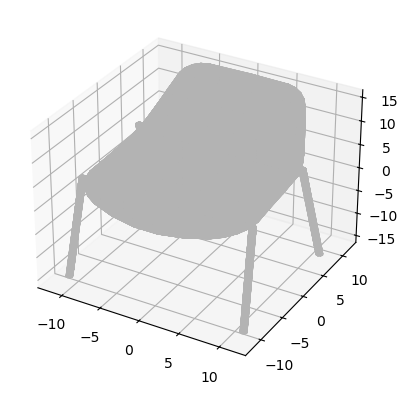

In [95]:
from mpl_toolkits import mplot3d
# from matplotlib import pyplot
import matplotlib.pyplot as plt

# Create a new plot
figure = plt.figure()
axes = figure.add_subplot(projection='3d')

# Load the STL files and add the vectors to the plot
your_mesh = off_to_stl("/home/student/work/3d_Generative/model/dataset/chair_0890.off")
poly_collection = mplot3d.art3d.Poly3DCollection(your_mesh.vectors)
poly_collection.set_color((0.7,0.7,0.7))  # play with color
axes.add_collection3d(poly_collection)

# Show the plot to the screen
plt.show()